In [1]:
import pandas as pd
import numpy as np

# 1. Load Data (Filtering for one store to save memory)
sales = pd.read_csv('sales_train_evaluation.csv')
sales = sales[sales['store_id'] == 'CA_1'] 

# 2. Melt the data from "Wide" to "Long"
# This turns d_1, d_2... into a column called 'day'
sales_long = pd.melt(sales, 
                     id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
                     var_name='day', 
                     value_name='sales')

# 3. Load and Merge Calendar
calendar = pd.read_csv('calendar.csv')
# We merge on the 'd' column (d_1, d_2, etc)
data = pd.merge(sales_long, calendar, left_on='day', right_on='d', how='left')

# 4. Clean up
data.drop(['d', 'day'], axis=1, inplace=True)
print(data.head())

                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  sales        date  wm_yr_wk   weekday  wday  month  year  \
0       CA      0  2011-01-29     11101  Saturday     1      1  2011   
1       CA      0  2011-01-29     11101  Saturday     1      1  2011   
2       CA      0  2011-01-29     11101  Saturday     1      1  2011   
3       CA      0  2011-01-29     11101  Saturday     1      1  2011   
4       CA      0  2011-01-29     11101  Saturday     1      1  2011   

  event_name_1 event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  \
0          

In [2]:
# 1. Downcast numbers to save RAM
def downcast(df):
    cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in cols:
        df[col] = pd.to_numeric(df[col], downcast='integer' if 'int' in str(df[col].dtype) else 'float')
    return df

data = downcast(data)

# 2. Merge Sell Prices
# Note: Sell prices are indexed by wm_yr_wk (week number)
prices = pd.read_csv('sell_prices.csv')
data = data.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# 3. Create a "Price Change" Feature (Advanced Skill)
# This shows if the price is higher or lower than the previous week
data['price_momentum'] = data['sell_price'] / data.groupby(['id'])['sell_price'].transform(lambda x: x.shift(1))

print("Optimization and Price Merge Complete!")
print(data[['id', 'date', 'sales', 'sell_price', 'price_momentum']].head())

Optimization and Price Merge Complete!
                              id        date  sales  sell_price  \
0  HOBBIES_1_001_CA_1_evaluation  2011-01-29      0         NaN   
1  HOBBIES_1_002_CA_1_evaluation  2011-01-29      0         NaN   
2  HOBBIES_1_003_CA_1_evaluation  2011-01-29      0         NaN   
3  HOBBIES_1_004_CA_1_evaluation  2011-01-29      0         NaN   
4  HOBBIES_1_005_CA_1_evaluation  2011-01-29      0         NaN   

   price_momentum  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  


In [ ]:
# 1. Create Lags (Looking back in time)
# We group by 'id' so we don't accidentally mix sales from different items
lags = [7, 28, 30]
for lag in lags:
    data[f'lag_{lag}'] = data.groupby(['id'])['sales'].transform(lambda x: x.shift(lag))

# 2. Create Rolling Windows (Averaging the last 7 days)
# This smooths out the "noise" and shows the trend
data['rolling_mean_7'] = data.groupby(['id'])['sales'].transform(lambda x: x.shift(7).rolling(window=7).mean())

# 3. Handle the NaN values
# We drop the first few weeks of data because they won't have lags yet
data.dropna(subset=['lag_30', 'rolling_mean_7'], inplace=True)

print("Lag Engineering Complete!")
print(data[['id', 'date', 'sales', 'lag_7', 'rolling_mean_7']].tail())

Random Forest Training Complete!


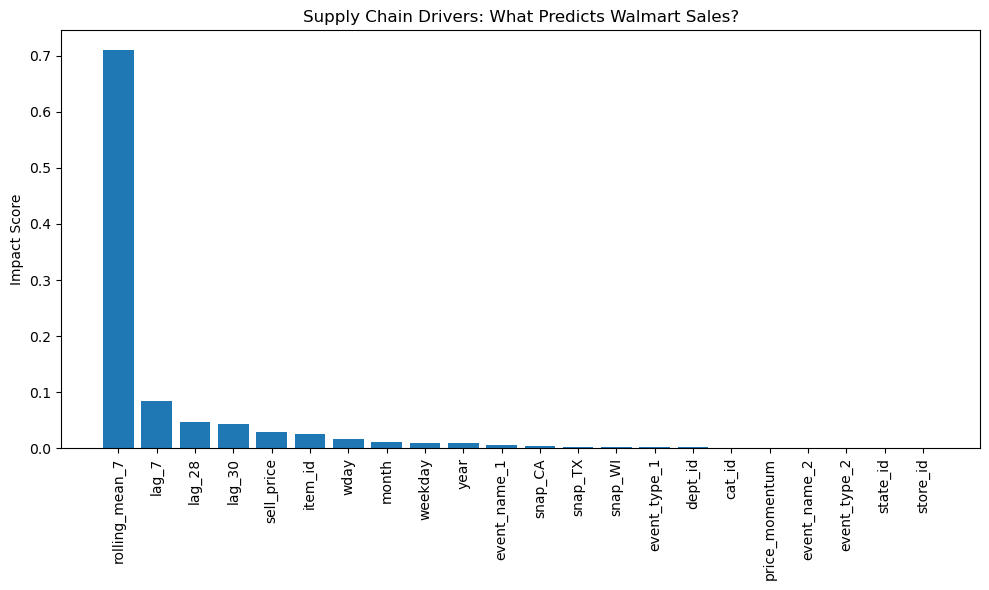

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# 1. Final String-to-Number Cleaning
# This ensures that 'OrthodoxEaster' and other events are converted to unique IDs
text_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

for col in text_cols:
    le = LabelEncoder()
    # Fill actual 'NaN' values with 'None' first so the encoder treats it as a category
    data[col] = data[col].fillna('None').astype(str)
    data[col] = le.fit_transform(data[col])

# 2. Re-Define Features (Ensuring everything is a number)
features = [col for col in data.columns if col not in ['id', 'sales', 'date', 'wm_yr_wk']]
target = 'sales'

# 3. Split the data
train_data = data[data['date'] < '2016-04-25'].sample(100000) 
x_train = train_data[features]
y_train = train_data[target]

x_val = data[data['date'] >= '2016-04-25'][features]
y_val = data[data['date'] >= '2016-04-25'][target]

# 4. Initialize and Train
rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(x_train, y_train)

print("Random Forest Training Complete!")

# 5. Visualize Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Supply Chain Drivers: What Predicts Walmart Sales?")
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=90)
plt.ylabel("Impact Score")
plt.tight_layout()
plt.show()

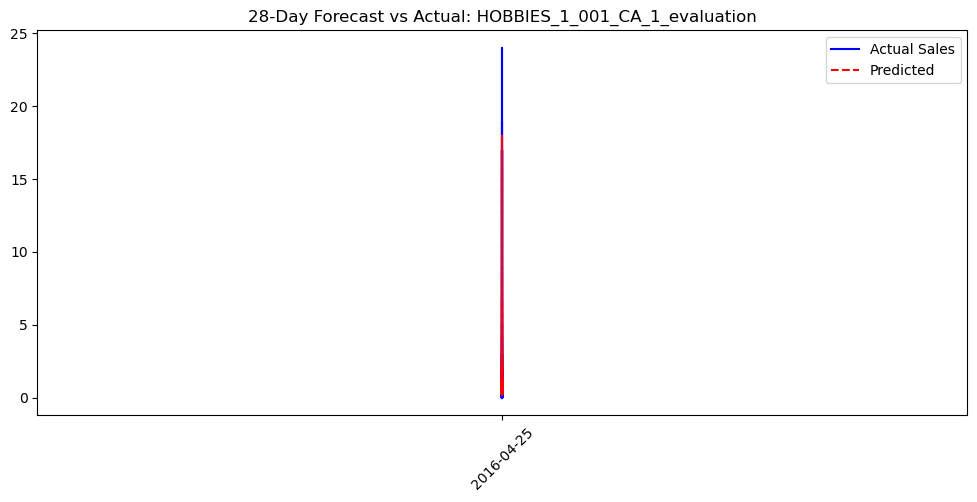

In [7]:
# Select one item to visualize
sample_id = x_val.index[0] 
item_name = data.loc[sample_id, 'id']

plt.figure(figsize=(12, 5))
plt.plot(data.loc[x_val.index[:100], 'date'], y_val[:100], label='Actual Sales', color='blue')
plt.plot(data.loc[x_val.index[:100], 'date'], rf.predict(x_val[:100]), label='Predicted', color='red', linestyle='--')
plt.title(f"28-Day Forecast vs Actual: {item_name}")
plt.xticks(rotation=45)
plt.legend()
plt.show()